# Building a Large Language Model From Scratch

**Book Reference:** *Build a Large Language Model (From Scratch)*  -  Sebastian Raschka, Manning Publications
**Course:** Independent Study

---

This notebook walks through the process of building a **GPT-style Large Language Model (LLM)** completely from scratch using Python and PyTorch. Every concept, every technical term, and every code block is explained in plain language so you can follow the reasoning  -  not just the code.

We are recreating the architecture behind **GPT-2**, a model released by OpenAI that can generate human-like text. By the end of this notebook, you will understand how a language model works at a deep level  -  from raw text all the way to generating new sentences.

---

## Table of Contents
1. Setup & Dependencies
2. Loading & Tokenizing Text
3. Building a Vocabulary
4. Simple Tokenizer Classes (V1 & V2)
5. BPE Tokenization with tiktoken
6. Sliding Window Data Sampling
7. Token & Positional Embeddings
8. Simple Self-Attention (Step by Step)
9. Scaled Dot-Product Attention
10. Self-Attention Classes (V1 & V2)
11. Causal (Masked) Attention
12. Multi-Head Attention
13. GPT Model Architecture
14. Layer Normalization
15. GELU Activation & Feed-Forward Network
16. Shortcut (Residual) Connections
17. Transformer Block & Full GPT Model
18. Text Generation
19. Training the Model
20. Decoding Strategies  -  Temperature & Top-k Sampling
21. Saving & Loading the Model
22. Loading Pretrained GPT-2 Weights
23. Summary


---
## 1. Setup & Dependencies

### What is a dependency?
A **dependency** is an external library or package that your code needs in order to run. Instead of writing everything from scratch, we install pre-built tools made by other developers.

### What are we installing?
- **`tiktoken`**: A tokenizer library released by OpenAI. A *tokenizer* is a tool that breaks text into smaller pieces (tokens) that the model can process. This specific tokenizer is the same one used inside GPT-2 and GPT-4.
- **`jupyterlab`**: The interface that lets you run notebooks like this one interactively, cell by cell.

Everything else we need  -  **PyTorch** (the deep learning framework), **NumPy** (for numerical operations), and **Matplotlib** (for plotting graphs)  -  is assumed to already be installed in the environment.


In [1]:
!pip install tiktoken jupyterlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 206.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 147.0 MB/s eta 0:00:00


---
## 2. Loading & Tokenizing Text

### Why do we need text data?
A language model learns by reading enormous amounts of text. It learns patterns  -  which words tend to follow which other words, how sentences are structured, what topics relate to each other. Without training data, the model has nothing to learn from.

### What text are we using?
We use *The Verdict*, a short story by Edith Wharton. It is small enough to run quickly on any machine, yet rich enough in vocabulary and sentence structure to demonstrate everything we need.

### What is tokenization?
**Tokenization** is the process of breaking raw text into smaller units called **tokens**. A token can be a word, a part of a word, or even a punctuation mark. Language models do not read characters or words directly  -  they read *token IDs*, which are just numbers. The tokenizer converts text into numbers, and those numbers are what the model actually processes.

Think of it like translating English into a number code before feeding it into a machine.

### Why use regular expressions for splitting?
A **regular expression (regex)** is a pattern used to search or split text. We use it here to split the story into individual tokens by cutting at spaces, commas, periods, and other punctuation. We build this regex step by step below, showing exactly why each version improves on the last.


In [2]:
import urllib.request
import re

# Download the training text from the book's official GitHub repository
url = ("https://raw.githubusercontent.com/rasbt/"
       "LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt")
urllib.request.urlretrieve(url, "the-verdict.txt")

with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total characters:", len(raw_text))
print("Preview of first 99 characters:")
print(raw_text[:99])

Total characters: 20479
Preview of first 99 characters:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


### Building the Tokenizer Step by Step

We start with the simplest possible split and add complexity as we see problems.

**Step 1  -  Split only on whitespace:**
This separates words but keeps punctuation glued to words. For example, `"world."` stays as one token instead of becoming `"world"` and `"."` separately. That is a problem because the model would treat `"world"` and `"world."` as completely different things.


In [3]:
# Step 1: Split only on whitespace  -  punctuation stays attached to words
text = "Hello, world. This is a test."
result = re.split(r'(\s)', text)
print("Step 1 (whitespace only):", result)

Step 1 (whitespace only): ['Hello,', ' ', 'world.', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test.']


**Step 2  -  Also split on commas and periods:**
Now punctuation gets its own token. But we still get empty strings and leftover whitespace tokens in the list.


In [4]:
# Step 2: Split on whitespace AND commas/periods
result = re.split(r'([,.]|\s)', text)
print("Step 2 (punctuation added):", result)

Step 2 (punctuation added): ['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


**Step 3  -  Remove empty and whitespace-only items:**
After splitting, we filter out anything that is blank or just a space. Now we have clean tokens.


In [5]:
# Step 3: Clean up empty tokens
result = [item.strip() for item in result if item.strip()]
print("Step 3 (cleaned):", result)

Step 3 (cleaned): ['Hello', ',', 'world', '.', 'This', 'is', 'a', 'test', '.']


**Step 4  -  Handle all punctuation types:**
Real text has dashes, question marks, exclamation marks, quotes, and more. We expand the regex to handle all of them. The `|` symbol in regex means "or", so this pattern matches any of these punctuation characters OR whitespace.


In [6]:
# Step 4: Full punctuation set  -  handles real prose
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()'']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print("Step 4 (full punctuation):", result)

Step 4 (full punctuation): ['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1835/3486840803.py:3: SyntaxWarning: invalid escape sequence '\s'
  result = re.split(r'([,.:;?_!"()'']|--|\s)', text)


In [7]:
# Apply the final regex to the entire training corpus
preprocessed = re.split(r'([,.:;?_!"()'']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

print(f"Total tokens in the corpus: {len(preprocessed)}")
print("First 30 tokens:", preprocessed[:30])

Total tokens in the corpus: 4519
First 30 tokens: ['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1835/2172725174.py:2: SyntaxWarning: invalid escape sequence '\s'
  preprocessed = re.split(r'([,.:;?_!"()'']|--|\s)', raw_text)


---
## 3. Building a Vocabulary

### What is a vocabulary?
A **vocabulary** is a complete list of every unique token that the model knows about, along with a unique integer ID for each one. Think of it as a dictionary  -  but instead of definitions, each word maps to a number.

For example:
- `"apple"` -> `0`
- `"banana"` -> `1`
- `"cherry"` -> `2`

### Why do we need this?
Neural networks  -  including language models  -  cannot process text directly. They can only work with numbers. The vocabulary is the lookup table that converts every word or token into a number the model can compute with.

### Why sort alphabetically?
We sort all unique tokens alphabetically before assigning IDs. This ensures the mapping is **deterministic**  -  meaning if you run the code again tomorrow, you get the exact same vocabulary in the exact same order. Without sorting, the order could be random and the model would produce different results on each run.


In [8]:
# Collect all unique tokens, sort them alphabetically, assign an integer ID to each
all_words  = sorted(set(preprocessed))
vocab_size = len(all_words)
print(f"Vocabulary size: {vocab_size}")

# vocab maps: token (string) -> integer ID
vocab = {token: integer for integer, token in enumerate(all_words)}

# Preview the first 50 entries
for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

Vocabulary size: 1154
('!', 0)
('"', 1)
("'", 2)
("'Are", 3)
("'It's", 4)
("'coming'", 5)
("'done'", 6)
("'subject", 7)
("'technique'", 8)
("'way", 9)
('(', 10)
(')', 11)
(',', 12)
('--', 13)
('.', 14)
(':', 15)
(';', 16)
('?', 17)
('A', 18)
('Ah', 19)
('Among', 20)
('And', 21)
('Arrt', 22)
('As', 23)
('At', 24)
('Be', 25)
('Begin', 26)
('Burlington', 27)
('But', 28)
('By', 29)
('Carlo', 30)
('Chicago', 31)
('Claude', 32)
('Come', 33)
('Croft', 34)
('Destroyed', 35)
('Devonshire', 36)
("Don't", 37)
('Dubarry', 38)
('Emperors', 39)
('Florence', 40)
('For', 41)
('Gallery', 42)
('Gideon', 43)
('Gisburn', 44)
("Gisburn's", 45)
('Gisburns', 46)
('Grafton', 47)
('Greek', 48)
('Grindle', 49)
("Grindle's", 50)


---
## 4. Simple Tokenizer Classes (V1 & V2)

### What is a class in Python?
A **class** is a blueprint for creating reusable objects. Instead of writing the same logic every time we want to tokenize text, we wrap it inside a class with methods we can call over and over.

### The two core methods every tokenizer must have:
- **`encode(text)`**  -  takes a string of text and returns a list of integer token IDs. This is the direction: *text -> numbers*.
- **`decode(ids)`**  -  takes a list of integers and returns the original text string. This is the reverse: *numbers -> text*.

These two methods are the contract every tokenizer must fulfill, from our simple version all the way to the ones used inside GPT-4.

---

### V1: Basic Tokenizer

This version works perfectly as long as every word in the input already exists in the vocabulary. If you try to encode a word it has never seen, it will crash with a `KeyError`.


In [9]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        # str_to_int: look up a token and get its integer ID
        self.str_to_int = vocab
        # int_to_str: the reverse  -  look up an integer and get the token back
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        # Split the input text into tokens using the same regex as before
        preprocessed = re.split(r'([,.?_!"()'']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        # Convert each token to its integer ID
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids

    def decode(self, ids):
        # Convert each integer ID back to its token string
        text = " ".join([self.int_to_str[i] for i in ids])
        # Remove the spaces we added before punctuation (cosmetic fix)
        text = re.sub(r'\s+([,.?!()'"''.])', r'', text)
        return text


tokenizer = SimpleTokenizerV1(vocab)
sample    = "It was the last one he painted, you know."
ids       = tokenizer.encode(sample)
print("Encoded token IDs:", ids)
print("Decoded back to text:", tokenizer.decode(ids))

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1835/1612162297.py:10: SyntaxWarning: invalid escape sequence '\s'
  preprocessed = re.split(r'([,.?_!"()'']|--|\s)', text)


SyntaxError: unterminated string literal (detected at line 20) (1612162297.py, line 20)

---
### V2: Tokenizer with Special Tokens

**The problem with V1:** If the input contains a word that was never in the training text, V1 crashes. For example, the name *"Einstein"* would not be in a vocabulary built from one short story.

**The solution  -  special tokens:** We add two reserved tokens that have special meaning:

- **`<|unk|>`** (unknown): Any word not found in the vocabulary is replaced with this token instead of crashing. The model learns that this token means "something I haven't seen before."

- **`<|endoftext|>`** (end of text): This token is inserted between separate documents in the training data. It signals to the model where one piece of text ends and a completely unrelated one begins. This prevents the model from carrying context across document boundaries  -  for example, a story about cats should not influence the next story about finance.

Both GPT-2 and GPT-3 use `<|endoftext|>` extensively in their training pipelines for exactly this reason.


In [10]:
# Add the two special tokens to the vocabulary
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token: integer for integer, token in enumerate(all_tokens)}

print(f"Vocabulary size (with special tokens): {len(vocab)}")
print("Last 5 entries:", list(vocab.items())[-5:])

Vocabulary size (with special tokens): 1156
Last 5 entries: [('younger', 1151), ('your', 1152), ('yourself', 1153), ('<|endoftext|>', 1154), ('<|unk|>', 1155)]


In [14]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i: s for s, i in vocab.items()}

    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()'']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        # Replace any unknown token with <|unk|> instead of crashing
        preprocessed = [
            item if item in self.str_to_int else "<|unk|>"
            for item in preprocessed
        ]
        return [self.str_to_int[s] for s in preprocessed]

    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        text = re.sub(r"\s+([,.?!()'\".])", r"", text)
        return text


# Demonstrate: two unrelated sentences separated by <|endoftext|>
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
combined = " <|endoftext|> ".join([text1, text2])

tok = SimpleTokenizerV2(vocab)
print("Input text:", combined)
print("Encoded:   ", tok.encode(combined))
print("Decoded:   ", tok.decode(tok.encode(combined)))

Input text: Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.
Encoded:    [1155, 12, 372, 1148, 651, 995, 17, 1154, 67, 1007, 977, 1003, 744, 1007, 1155, 14]
Decoded:    <|unk|> do you like tea <|endoftext|> In the sunlit terraces of the <|unk|>


<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1835/2320357771.py:7: SyntaxWarning: invalid escape sequence '\s'
  preprocessed = re.split(r'([,.:;?_!"()'']|--|\s)', text)


---
## 5. BPE Tokenization with tiktoken

### The problem with our simple tokenizer
Our regex-based tokenizer splits only on whitespace and punctuation. This creates two serious problems:
1. Words not seen in training get replaced with `<|unk|>`, losing all information about them.
2. The vocabulary grows too large if you try to include every word from a large dataset (millions of unique words).

### What is Byte-Pair Encoding (BPE)?
**Byte-Pair Encoding (BPE)** is a smarter tokenization strategy. Instead of splitting on spaces, it learns *subword units* from the data during a training phase of its own.

Here is the core idea: BPE starts with individual characters and repeatedly merges the most frequently co-occurring pair of tokens into a new token. After many merges, you end up with a vocabulary of common words, common word-pieces, and individual characters.

**Why this is powerful:**
- The word `"unbelievable"` might not be in the vocabulary, but `"un"`, `"believ"`, and `"able"` probably are  -  so the word can still be represented without falling back to `<|unk|>`.
- Rare or made-up words like `"someunknownPlace"` get broken into recognizable parts rather than lost entirely.

### What is tiktoken?
**`tiktoken`** is the specific BPE implementation used by OpenAI in GPT-2, GPT-3, and GPT-4. GPT-2's vocabulary contains exactly **50,257 tokens**. We use tiktoken here so our tokenization is identical to what OpenAI used.


In [15]:
!pip install tiktoken

In [16]:
from importlib.metadata import version
import tiktoken

print("tiktoken version:", version("tiktoken"))

# Load the GPT-2 tokenizer  -  this uses the exact same BPE rules as GPT-2
tokenizer = tiktoken.get_encoding("gpt2")

tiktoken version: 0.12.0


In [17]:
# Demonstrate BPE handling an unknown word
# "someunknownPlace" is not a real word, but BPE splits it into known subpieces
text     = "Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace."
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print("Token IDs:", integers)
print("Decoded:  ", tokenizer.decode(integers))
print(f"\n'someunknownPlace' was split into subword pieces instead of becoming <|unk|>")

Token IDs: [15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 286, 617, 34680, 27271, 13]
Decoded:   Hello, do you like tea? <|endoftext|> In the sunlit terraces of someunknownPlace.

'someunknownPlace' was split into subword pieces instead of becoming <|unk|>


In [18]:
# Encode the full training text and check total token count
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(f"Total tokens in the corpus: {len(enc_text)}")

Total tokens in the corpus: 5145


---
## 6. Sliding Window Data Sampling

### How does a language model learn?
A language model is trained on one core task: **predict the next token given all the previous tokens**. It sees a sequence of tokens and must guess what comes next. Over millions of such predictions, it learns the patterns of language.

### What is a sliding window?
To create training examples from our text, we use a **sliding window** approach. We take a chunk of tokens as the **input** and the same chunk shifted one position to the right as the **target** (the correct answer):

```
Text:   [The, cat, sat, on, the, mat]
Input:  [The, cat, sat, on]   -> Target: [cat, sat, on, the]
```

At each position, the model is asked: *given everything before this point, what comes next?*

### What is stride?
**Stride** controls how much the window moves forward between consecutive samples:
- `stride = 1`: The window moves one token at a time. Maximum overlap  -  lots of training samples, but they are highly correlated.
- `stride = max_length`: The window jumps forward by a full window width. No overlap  -  fewer but fully independent training samples.

### What is a Dataset and DataLoader?
- A **`Dataset`** in PyTorch is a class that stores your data and knows how to return one sample at a time.
- A **`DataLoader`** wraps the Dataset and handles batching (grouping samples together), shuffling (randomizing order each epoch), and parallelism (loading data on multiple CPU cores).

Together they form the standard pipeline for feeding data into a PyTorch model.


In [19]:
# Visualize the sliding window concept on a small example
enc_sample   = enc_text[50:]   # skip first 50 tokens for variety
context_size = 4               # window size = 4 tokens

x = enc_sample[:context_size]        # input window
y = enc_sample[1:context_size + 1]   # target window (shifted by 1)

print(f"Input  token IDs: {x}")
print(f"Target token IDs: {y}")
print()

# Show each prediction task at each position
for i in range(1, context_size + 1):
    context = enc_sample[:i]
    desired = enc_sample[i]
    print(f"  Input: {tokenizer.decode(context):30s}  -->  Next token: '{tokenizer.decode([desired])}'")

Input  token IDs: [290, 4920, 2241, 287]
Target token IDs: [4920, 2241, 287, 257]

  Input:  and                            -->  Next token: ' established'
  Input:  and established                -->  Next token: ' himself'
  Input:  and established himself        -->  Next token: ' in'
  Input:  and established himself in     -->  Next token: ' a'


In [20]:
import torch
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    '''
    Converts a raw text string into (input, target) tensor pairs
    using a sliding window approach.

    Parameters:
        txt        : the full training text as a string
        tokenizer  : a tiktoken tokenizer instance
        max_length : how many tokens per input sample (the context window size)
        stride     : how many tokens to move the window forward each step
    '''
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids  = []
        self.target_ids = []

        # Tokenize the entire text into a flat list of integer IDs
        token_ids = tokenizer.encode(txt)

        # Slide the window across the token list
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk  = token_ids[i : i + max_length]
            target_chunk = token_ids[i + 1 : i + max_length + 1]  # shifted by 1
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        # Returns the total number of samples in the dataset
        return len(self.input_ids)

    def __getitem__(self, idx):
        # Returns the input/target pair at position idx
        return self.input_ids[idx], self.target_ids[idx]

In [21]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, stride=128,
                         shuffle=True, drop_last=True, num_workers=0):
    '''
    Convenience function: builds a GPTDatasetV1 and wraps it in a DataLoader.

    Parameters:
        batch_size  : how many samples to group together per training step
        max_length  : context window size in tokens
        stride      : sliding window stride
        shuffle     : if True, randomize sample order each epoch (for training)
        drop_last   : if True, drop the final batch if it is smaller than batch_size
                      (keeps batch sizes uniform, which is important for efficiency)
        num_workers : number of CPU worker processes for loading data in parallel
    '''
    tok    = tiktoken.get_encoding("gpt2")
    ds     = GPTDatasetV1(txt, tok, max_length, stride)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      drop_last=drop_last, num_workers=num_workers)


# Example: stride=1, window=4  -  maximum overlap
dl = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)
it = iter(dl)
print("Batch 1 [input, target]:", next(it))
print("Batch 2 [input, target]:", next(it))
print("\nNotice: batch 2 is batch 1 shifted by exactly one token (stride=1)")

Batch 1 [input, target]: [tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
Batch 2 [input, target]: [tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]

Notice: batch 2 is batch 1 shifted by exactly one token (stride=1)


In [22]:
# Practical training setup: batch_size=8, non-overlapping windows
dl = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)
inputs, targets = next(iter(dl))
print("Inputs shape:", inputs.shape)   # [8 samples, 4 tokens each]
print("Inputs:\n",  inputs)
print("\nTargets (same but shifted right by 1):\n", targets)

Inputs shape: torch.Size([8, 4])
Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets (same but shifted right by 1):
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


---
## 7. Token & Positional Embeddings

### What is an embedding?
An **embedding** is a way of representing a discrete item (like a token ID) as a continuous, dense vector of real numbers. Instead of the model just knowing *"token 42"*, it knows a rich vector like `[0.32, -0.11, 0.87, ...]` where each number captures some aspect of that token's meaning.

These vectors are **learned**  -  they start random and get updated during training until tokens with similar meanings end up with similar vectors.

### Why not just use the token ID number directly?
Token ID numbers are arbitrary. Token 42 is not "more" than token 41 in any meaningful sense  -  they are just labels. Embedding vectors, on the other hand, can encode relationships. After training, words like "king" and "queen" will have vectors that are close to each other in the embedding space.

### Why do we need TWO embeddings?
The Transformer's attention mechanism is inherently **position-blind**  -  it treats a sequence as a set, not an ordered list. If you swapped the first and last word, the attention mechanism would produce the same output. That is clearly wrong for language.

To fix this, we add a second embedding that encodes **where** in the sequence each token appears:

1. **Token embedding**  -  encodes *what* this token is (its meaning/identity)
2. **Positional embedding**  -  encodes *where* this token appears (its position in the sequence)

The final input to the model is the **sum** of both. This way the model gets both pieces of information for every token.

### What is `nn.Embedding`?
`nn.Embedding(vocab_size, emb_dim)` creates a lookup table with `vocab_size` rows and `emb_dim` columns. Each row is the embedding vector for one token. Looking up token ID 42 just returns row 42 from this table. The table values are learnable parameters  -  they get updated during training via backpropagation.


In [23]:
# Small demo: vocab of 6 tokens, 3-dimensional embedding vectors
input_ids = torch.tensor([2, 3, 5, 1])
torch.manual_seed(123)
emb = torch.nn.Embedding(6, 3)   # 6 tokens, each mapped to a 3-dim vector

print("Full embedding table (6 tokens x 3 dimensions):")
print(emb.weight)
print("\nEmbedding for token ID 3 (just row 3 of the table):")
print(emb(torch.tensor([3])))
print("\nEmbeddings for all 4 input tokens:")
print(emb(input_ids))

Full embedding table (6 tokens x 3 dimensions):
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)

Embedding for token ID 3 (just row 3 of the table):
tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

Embeddings for all 4 input tokens:
tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


In [24]:
# Full GPT-2 scale: 50,257 token vocabulary, 256-dimensional embeddings
token_embedding_layer = torch.nn.Embedding(50257, 256)

max_length = 4
dl         = create_dataloader_v1(raw_text, batch_size=8,
                                   max_length=max_length, stride=max_length, shuffle=False)
inputs, targets = next(iter(dl))

# Look up the embedding vector for every token in every sample
token_embeddings = token_embedding_layer(inputs)
print("Token IDs shape:           ", inputs.shape)            # [8 samples, 4 tokens]
print("Token embeddings shape:    ", token_embeddings.shape)  # [8 samples, 4 tokens, 256 dims]

# Create positional embeddings  -  one vector per position index (0, 1, 2, 3)
pos_embedding_layer = torch.nn.Embedding(max_length, 256)
pos_embeddings      = pos_embedding_layer(torch.arange(max_length))
print("Positional embeddings shape:", pos_embeddings.shape)   # [4 positions, 256 dims]

# Add token + positional embeddings
# PyTorch broadcasting automatically adds [4, 256] to each of the 8 samples
input_embeddings = token_embeddings + pos_embeddings
print("Final input embeddings shape:", input_embeddings.shape)  # [8, 4, 256]
print("\nEach token now carries both its identity AND its position in the sequence.")

Token IDs shape:            torch.Size([8, 4])
Token embeddings shape:     torch.Size([8, 4, 256])
Positional embeddings shape: torch.Size([4, 256])
Final input embeddings shape: torch.Size([8, 4, 256])

Each token now carries both its identity AND its position in the sequence.


---
## 8. Simple Self-Attention (Step by Step)

### What is self-attention?
**Self-attention** is the mechanism that allows every token in a sequence to look at every other token and decide how much to borrow information from each. It is the heart of the Transformer architecture.

**Intuitive example:** Consider the sentence: *"The animal didn't cross the street because it was too tired."*

What does "it" refer to  -  the animal or the street? A human reads the full context and concludes it's the animal. Self-attention gives the model the same ability: when processing the token "it", the model can look back at all other tokens and assign high attention weight to "animal", pulling information from it to understand what "it" means.

### How does it work? Three steps:

**Step 1  -  Attention Scores:**
For a given token (the "query" token), we compute a dot product between its embedding vector and every other token's embedding vector. The **dot product** is a scalar value that measures how aligned two vectors are  -  if two vectors point in the same direction, their dot product is large. In attention, a large dot product means "this token is highly relevant to my query."

**Step 2  -  Softmax Normalization:**
Raw dot product scores can be any number  -  negative, positive, very large. We apply **softmax** to convert them into a proper probability distribution: all values become positive and sum to exactly 1.0. This makes the scores interpretable as "what fraction of my attention goes to each token."

**The softmax function:** For a vector `[a, b, c]`, softmax computes `[e^a, e^b, e^c] / (e^a + e^b + e^c)`. The `e^x` (exponential) ensures all values are positive, and dividing by the sum normalizes them to sum to 1.

**Step 3  -  Context Vector:**
The **context vector** is the weighted average of all token embeddings, where the weights are the attention weights from Step 2. Tokens that received high attention weight contribute more to the context vector. The context vector is what the model uses to represent the query token in its "attended" form  -  enriched with relevant information from the rest of the sequence.


In [25]:
import torch

# Six hand-crafted 3-dimensional token embedding vectors
# (In practice these come from the learned embedding table, not hardcoded)
inputs = torch.tensor([
  [0.43, 0.15, 0.89],  # Token: "Your"    (x_1)
  [0.55, 0.87, 0.66],  # Token: "journey" (x_2)  <- this is our query token
  [0.57, 0.85, 0.64],  # Token: "starts"  (x_3)
  [0.22, 0.58, 0.33],  # Token: "with"    (x_4)
  [0.77, 0.25, 0.10],  # Token: "one"     (x_5)
  [0.05, 0.80, 0.55],  # Token: "step"    (x_6)
])
print("Input shape:", inputs.shape)  # [6 tokens, 3 dimensions each]

Input shape: torch.Size([6, 3])


In [26]:
# ── STEP 1: Compute raw attention scores via dot products ──────────────────
#
# For each token x_i, we compute: score = dot(x_i, query)
# The query here is x_2 ("journey")  -  we want to know which other tokens
# are most relevant when the model is processing "journey".
#
# Dot product formula: sum(a[i] * b[i]) for each dimension i
# This measures directional alignment between two vectors.

query         = inputs[1]   # x_2 = "journey"
attn_scores_2 = torch.tensor([torch.dot(x_i, query) for x_i in inputs])
print("Raw attention scores (one per token):", attn_scores_2)
print("\nHigher score = more relevant to the query token 'journey'")

Raw attention scores (one per token): tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

Higher score = more relevant to the query token 'journey'


**Why use dot product as a similarity measure?**
The dot product is large when two vectors point in the same direction (high cosine similarity). In the embedding space, tokens with similar meanings tend to have similar vectors. So a high dot product between the query and another token means that token is semantically related to the query  -  it should receive more attention.


In [27]:
# ── STEP 2: Normalize with softmax -> attention weights ─────────────────────
#
# Why softmax over simple division (like dividing by the sum)?
#   - Simple division could produce negative weights (from negative scores)
#   - Negative attention weights have no meaningful interpretation
#   - Softmax's exponential ensures all weights are positive
#   - The result is a proper probability distribution (sums to 1.0)

attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights (after softmax):", attn_weights_2)
print("Sum of weights (must be 1.0):     ", attn_weights_2.sum().item())
print("\nAll weights are positive and sum to 1  -  these are the 'attention fractions'")

Attention weights (after softmax): tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of weights (must be 1.0):      1.0

All weights are positive and sum to 1  -  these are the 'attention fractions'


In [28]:
# ── STEP 3: Compute the context vector ─────────────────────────────────────
#
# The context vector is the weighted average of ALL token embeddings.
# Tokens with high attention weight contribute more to the result.
# This produces an enriched representation of "journey" that includes
# relevant information borrowed from the other tokens in the sequence.

context_vec_2 = sum(attn_weights_2[i] * inputs[i] for i in range(len(inputs)))
print("Context vector for 'journey':", context_vec_2)
print("\nThis is a blend of all 6 token vectors, weighted by relevance.")
print("Tokens most similar to 'journey' contributed the most to this result.")

Context vector for 'journey': tensor([0.4419, 0.6515, 0.5683])

This is a blend of all 6 token vectors, weighted by relevance.
Tokens most similar to 'journey' contributed the most to this result.


### Computing All Context Vectors at Once

Doing this for one query token at a time is slow. We can compute attention scores for **all tokens simultaneously** using matrix multiplication  -  one of the key reasons Transformers are efficient enough to train on modern hardware.

**Matrix multiplication trick:** `inputs @ inputs.T` computes all 36 pairwise dot products (6×6) in a single operation, producing a 6×6 score matrix where entry `[i, j]` is the attention score of token i attending to token j.


In [29]:
# inputs @ inputs.T computes all 6x6 pairwise dot products at once
# Result shape: [6, 6]  -  row i contains attention scores for token i vs all others
attn_scores  = inputs @ inputs.T

# Apply softmax along the last dimension (dim=-1) to normalize each row
# Each row becomes a probability distribution summing to 1.0
attn_weights = torch.softmax(attn_scores, dim=-1)

print("Full 6x6 attention weight matrix (each row sums to 1.0):")
print(attn_weights)
print("\nRow sums:", attn_weights.sum(dim=-1))

# Final step: weighted sum of input vectors for all 6 tokens at once
all_context_vecs = attn_weights @ inputs
print("\nAll 6 context vectors (shape [6, 3]):")
print(all_context_vecs)
print("\nRow 1 (for 'journey') matches our earlier manual calculation:", all_context_vecs[1])

Full 6x6 attention weight matrix (each row sums to 1.0):
tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

All 6 context vectors (shape [6, 3]):
tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

Row 1 (for 'journey') matches our earlier manual calculation: tensor([0.4419, 0.6515, 0.5683])


---
## 9. Scaled Dot-Product Attention

### What was missing in the simple version?
In Section 8, we used the raw input vectors directly as both queries and keys. This works as a demonstration, but it has a key limitation: the model has no way to learn *how* to compute attention. The attention pattern is entirely determined by the raw embedding vectors.

### The solution: Learnable projection matrices
Real self-attention introduces **three separate weight matrices** that are learned during training:

| Matrix | Symbol | What it does |
|--------|--------|--------------|
| Query matrix | **W_query** | Projects a token's embedding into a "query"  -  what this token is looking for |
| Key matrix | **W_key** | Projects a token's embedding into a "key"  -  what this token advertises about itself |
| Value matrix | **W_value** | Projects a token's embedding into a "value"  -  the actual information to be shared |

**The analogy:** Think of a library. Your **query** is the question you type into the search system. Each book has a **key** (its title/description). The system matches your query against all keys. The most matching books then share their **values** (their actual content) with you. The attention mechanism works exactly the same way.

### Why scale by √d_k?
When the embedding dimension `d_k` is large (e.g., 768 in GPT-2), dot products between high-dimensional vectors tend to grow very large in magnitude. Large dot products push softmax into **saturation**  -  the highest score gets nearly all the weight and the rest get almost zero. This creates near-zero gradients and makes training very slow.

Dividing the scores by √d_k keeps the values in a reasonable range before applying softmax, which keeps the gradient signal healthy during training.


In [30]:
x_2   = inputs[1]        # our query token "journey"
d_in  = inputs.shape[1]  # input dimension = 3
d_out = 2                 # output dimension (smaller here just for demonstration)

torch.manual_seed(123)
# Three separate learnable weight matrices
# requires_grad=False here since we are just demonstrating (not training)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

# Project x_2 into query space, and all tokens into key/value spaces
# Matrix multiplication x @ W transforms the vector into a new space
query_2 = x_2    @ W_query   # shape: [d_out]
keys    = inputs @ W_key     # shape: [6, d_out]
values  = inputs @ W_value   # shape: [6, d_out]

print("Query vector for 'journey':", query_2)
print("Keys shape (all tokens projected):", keys.shape)
print("Values shape:", values.shape)

Query vector for 'journey': tensor([0.4306, 1.4551])
Keys shape (all tokens projected): torch.Size([6, 2])
Values shape: torch.Size([6, 2])


In [31]:
# Compute scaled attention scores and the context vector
d_k            = keys.shape[-1]                                    # key dimension
attn_scores_2  = query_2 @ keys.T                                  # [1, 6] dot products
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)  # scale before softmax
context_vec_2  = attn_weights_2 @ values                           # weighted sum of values

print("Scaled attention weights:", attn_weights_2)
print("Context vector for 'journey':", context_vec_2)
print("\nDividing by sqrt(d_k) =", d_k**0.5, "prevents softmax saturation.")

Scaled attention weights: tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])
Context vector for 'journey': tensor([0.3061, 0.8210])

Dividing by sqrt(d_k) = 1.4142135623730951 prevents softmax saturation.


---
## 10. Self-Attention Classes (V1 & V2)

### Why put this in a class?
So far we have written attention as a sequence of operations. To use it inside a larger model that gets trained, we need it packaged as a proper PyTorch module  -  a class that inherits from `nn.Module`. This gives us automatic parameter tracking (so the optimizer knows what to update), the ability to call `.to(device)` to move everything to GPU, and a clean `forward()` method.

### V1 vs V2  -  what is the difference?

**V1 uses `nn.Parameter`:** We manually wrap the weight tensors in `nn.Parameter()`, which tells PyTorch "this is a learnable parameter  -  track it and update it during training."

**V2 uses `nn.Linear`:** `nn.Linear(in, out)` is PyTorch's built-in fully-connected layer. It internally stores a weight matrix and optionally a bias vector, and applies the linear transformation `x @ W.T` when called. Using `nn.Linear` is preferred in practice because:
- It uses highly optimized BLAS (Basic Linear Algebra Subprograms) routines under the hood
- It cleanly handles optional bias terms
- It is the standard idiom that other PyTorch users expect to see

Both V1 and V2 are mathematically equivalent  -  same computation, different implementation style.


In [32]:
import torch.nn as nn


class SelfAttention_v1(nn.Module):
    '''
    Self-attention using raw nn.Parameter weight matrices.
    Simple and explicit - good for understanding the mechanics.
    '''
    def __init__(self, d_in, d_out):
        super().__init__()
        # nn.Parameter tells PyTorch: these tensors are learnable, track gradients
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        # Project all tokens into Q, K, V spaces
        Q, K, V = x @ self.W_query, x @ self.W_key, x @ self.W_value
        # Compute scaled attention scores and weights
        scores  = Q @ K.T
        weights = torch.softmax(scores / K.shape[-1]**0.5, dim=-1)
        # Return context vectors for all tokens
        return weights @ V


torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print("Context vectors using V1 (nn.Parameter):")
print(sa_v1(inputs))

Context vectors using V1 (nn.Parameter):
tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [33]:
class SelfAttention_v2(nn.Module):
    '''
    Self-attention using nn.Linear  -  the preferred production approach.

    nn.Linear(in_features, out_features) applies y = x @ W.T
    It stores W internally and uses optimized BLAS routines.
    Using bias=False here because GPT-2 style attention omits bias in QKV projections.
    '''
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        # nn.Linear is equivalent to nn.Parameter but cleaner and faster
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        # Calling a Linear layer like a function applies the matrix multiplication
        Q, K, V = self.W_query(x), self.W_key(x), self.W_value(x)
        weights  = torch.softmax(Q @ K.T / K.shape[-1]**0.5, dim=-1)
        return weights @ V


torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print("Context vectors using V2 (nn.Linear):")
print(sa_v2(inputs))

Context vectors using V2 (nn.Linear):
tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


---
## 11. Causal (Masked) Attention

### The problem: attention can see the future
Standard self-attention lets every token attend to every other token  -  including tokens that come *after* it in the sequence. For a language model, this is cheating: when predicting the next word, the model must not be allowed to look at the answer.

**Example:** If the model is predicting the word at position 3, it should only see positions 0, 1, and 2. If it can see position 3 itself, it would trivially predict it correctly during training but fail completely at inference time when that future token doesn't exist yet.

### The solution: Causal masking
We create a **mask**  -  a matrix of 1s and 0s  -  where 1 means "this position is forbidden." We then replace the attention scores at forbidden positions with **negative infinity (−∞)** before applying softmax.

Why −∞? Because `softmax(−∞) = e^(−∞) / sum = 0`. So forbidden positions get exactly zero attention weight  -  they contribute nothing to the context vector.

The mask is a **lower triangular matrix** (zeros in the lower triangle, ones in the upper triangle), which means each token can only attend to itself and all tokens *before* it.

### Why use `register_buffer` for the mask?
The mask is not a learnable parameter  -  we never want to update it during training. But we do want it to automatically move to the GPU when we call `model.to(device)`. `register_buffer` does exactly this: it stores the tensor as part of the module's state without making it a parameter.

### What is Dropout?
**Dropout** is a regularization technique. During training, we randomly zero out a fraction of attention weights. This forces the model to not over-rely on any specific token relationship, which reduces overfitting and makes the model more robust.

The `dropout=0.1` setting means 10% of attention weights are randomly zeroed during each training step. At inference time (when generating text), dropout is turned off automatically when we call `model.eval()`.


In [34]:
# Demonstrate causal masking step by step
Q, K = sa_v2.W_query(inputs), sa_v2.W_key(inputs)
scores = Q @ K.T   # shape: [6, 6]
T      = scores.shape[0]

# torch.triu extracts the upper triangle (diagonal=1 excludes the main diagonal)
# This gives us 1 at every position a token should NOT attend to
mask   = torch.triu(torch.ones(T, T), diagonal=1).bool()
masked = scores.masked_fill(mask, -torch.inf)

print("Raw attention scores:")
print(scores)
print("\nAfter masking future positions with -inf:")
print(masked)
print("\nAfter softmax: -inf becomes 0, so no future token gets any attention")
weights = torch.softmax(masked / K.shape[-1]**0.5, dim=-1)
print(weights)

Raw attention scores:
tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)

After masking future positions with -inf:
tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)

After softmax: -inf becomes 0, so no future token gets any attention
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
     

In [35]:
class CausalAttention(nn.Module):
    '''
    Causal self-attention  -  the version used in autoregressive language models.

    Key additions over SelfAttention_v2:
    1. Causal mask: prevents attending to future tokens
    2. Dropout on attention weights: regularization to reduce overfitting
    3. Handles batched input of shape [batch_size, seq_len, d_in]
       (v2 only handled a single sequence, not a batch)
    '''
    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        # register_buffer: not a parameter, but part of module state (moves to GPU)
        self.register_buffer("mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, T, d_in = x.shape   # batch_size, sequence_length, embedding_dim
        Q, K, V    = self.W_query(x), self.W_key(x), self.W_value(x)

        # transpose(1,2) swaps the sequence and d_out dimensions for batch matrix multiply
        scores  = Q @ K.transpose(1, 2)
        # Apply the causal mask  -  only use the top-left [T x T] corner
        scores.masked_fill_(self.mask.bool()[:T, :T], -torch.inf)
        weights = self.dropout(torch.softmax(scores / K.shape[-1]**0.5, dim=-1))
        return weights @ V


# Test with a batch of 2 identical sequences
batch = torch.stack((inputs, inputs), dim=0)   # shape: [2, 6, 3]
torch.manual_seed(123)
ca = CausalAttention(d_in, d_out, context_length=6, dropout=0.0)
print("Output shape:", ca(batch).shape)   # [2 samples, 6 tokens, 2 dims each]

Output shape: torch.Size([2, 6, 2])


---
## 12. Multi-Head Attention

### Why not just one attention head?
A single attention head computes one set of Q/K/V projections  -  meaning it can only "look for" one type of relationship at a time. But language has many types of relationships simultaneously:
- Grammatical dependencies (subject ↔ verb)
- Semantic relationships (pronoun ↔ its referent)
- Positional patterns (words close together tend to be related)
- Topic coherence (words in the same domain cluster together)

**Multi-head attention** solves this by running several independent attention operations in parallel  -  each called a "head"  -  and then concatenating their outputs. Each head can specialize in a different type of pattern.

### How does it work?
We project Q, K, V into a space of size `d_out`, then **split** that space into `num_heads` chunks. Each chunk is one head and operates independently. At the end, the outputs of all heads are concatenated and passed through a final output projection.

**Efficient implementation:** Rather than creating `num_heads` separate Linear layers (one per head), we create one large Linear of size `d_out = num_heads × head_dim` and reshape the output. This is mathematically equivalent but much faster because we do one large matrix multiply instead of many small ones.

### What does the output projection do?
After concatenating all head outputs, we pass the result through one more Linear layer (`out_proj`). This allows the model to mix information from different heads before passing the result to the next layer. It also keeps the output dimension consistent with the input dimension, which is required for the residual connections we will see in Section 16.


In [36]:
class MultiHeadAttention(nn.Module):
    '''
    Efficient multi-head causal self-attention.

    Instead of num_heads separate Linear layers, we use ONE Linear of size d_out,
    then reshape the output to split it into num_heads independent attention heads.
    This is equivalent but significantly faster due to fewer kernel launches on GPU.

    Example: d_out=4, num_heads=2 -> each head gets 2 dimensions (head_dim=2)
    '''
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads   # dimension per head

        # Single large projection for all heads at once
        self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key    = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)   # mixes head outputs
        self.dropout  = nn.Dropout(dropout)
        self.register_buffer("mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, T, d_in = x.shape

        # Project to Q/K/V, then reshape into heads
        # [b, T, d_out] -> [b, T, num_heads, head_dim] -> [b, num_heads, T, head_dim]
        def split_heads(w):
            return w.view(b, T, self.num_heads, self.head_dim).transpose(1, 2)

        Q, K, V = split_heads(self.W_query(x)), split_heads(self.W_key(x)), split_heads(self.W_value(x))

        # Attention within each head: [b, heads, T, T]
        scores = Q @ K.transpose(2, 3)
        scores.masked_fill_(self.mask.bool()[:T, :T], -torch.inf)
        weights = self.dropout(torch.softmax(scores / K.shape[-1]**0.5, dim=-1))

        # Merge heads back: [b, heads, T, head_dim] -> [b, T, d_out]
        out = (weights @ V).transpose(1, 2).contiguous().view(b, T, self.d_out)
        return self.out_proj(out)   # final linear mix of all head outputs


torch.manual_seed(123)
mha = MultiHeadAttention(d_in=3, d_out=2, context_length=6, dropout=0.0, num_heads=2)
out = mha(batch)
print("Output shape:", out.shape)   # [2, 6, 2]
print("Each of the 2 heads captured d_out/2 = 1 dimension of information.")

Output shape: torch.Size([2, 6, 2])
Each of the 2 heads captured d_out/2 = 1 dimension of information.


---
## 13. GPT Model Architecture

### What is GPT?
**GPT** stands for *Generative Pre-trained Transformer*. It is a family of large language models developed by OpenAI. The "generative" part means it generates text. "Pre-trained" means it was first trained on a massive corpus of text before being fine-tuned for specific tasks. "Transformer" refers to the neural network architecture it uses  -  the same one we are building here.

### The configuration dictionary
Instead of hardcoding numbers throughout the code, we store all architecture hyperparameters in a Python dictionary called `GPT_CONFIG_124M`. This makes it easy to change the model size by just editing one place.

**What each hyperparameter means:**
- **`vocab_size = 50257`**: The total number of unique tokens the model knows. Every token must have an ID from 0 to 50256.
- **`context_length = 1024`**: The maximum number of tokens the model can process at once. Also called the "context window." The model cannot see anything further back than this.
- **`emb_dim = 768`**: The size of the vector used to represent each token. Larger = more expressive but slower and more memory-hungry.
- **`n_heads = 12`**: The number of attention heads per Transformer block. With `emb_dim=768` and `n_heads=12`, each head operates on `768/12 = 64` dimensions.
- **`n_layers = 12`**: The number of Transformer blocks stacked on top of each other. Depth allows the model to build increasingly abstract representations.
- **`drop_rate = 0.1`**: 10% dropout probability  -  10% of connections are randomly zeroed during training.
- **`qkv_bias = False`**: Whether to add a learnable bias term to the Q/K/V projections. GPT-2 does not use this, so we set it to False.

### The DummyGPTModel
Before building each real component, we create a skeleton ("dummy") model to verify that data flows correctly through the entire pipeline. The dummy transformer blocks and layer norms just pass data through unchanged  -  they are placeholders we will replace in later sections.


In [37]:
GPT_CONFIG_124M = {
    "vocab_size":     50257,   # Number of unique BPE tokens (GPT-2 vocabulary size)
    "context_length": 1024,    # Maximum number of tokens the model can process at once
    "emb_dim":        768,     # Embedding dimension for each token
    "n_heads":        12,      # Number of parallel attention heads per block
    "n_layers":       12,      # Number of stacked Transformer blocks
    "drop_rate":      0.1,     # Dropout probability (10% of connections zeroed during training)
    "qkv_bias":       False,   # No bias in QKV projections, following GPT-2 design
}

In [38]:
import tiktoken


class DummyTransformerBlock(nn.Module):
    # Placeholder for the real TransformerBlock (built in Section 17).
    def __init__(self, cfg): super().__init__()
    def forward(self, x):    return x   # pass-through, no transformation

class DummyLayerNorm(nn.Module):
    # Placeholder for the real LayerNorm (built in Section 14).
    def __init__(self, d, eps=1e-5): super().__init__()
    def forward(self, x): return x     # pass-through


class DummyGPTModel(nn.Module):
    '''
    Skeleton GPT model  -  verifies the full data flow is correct
    before we fill in the real components one by one.

    Data flow:
      Token IDs -> token embeddings + positional embeddings -> dropout
      -> N transformer blocks -> layer norm -> output head -> logits
    '''
    def __init__(self, cfg):
        super().__init__()
        # Token embedding: maps each token ID to a 768-dim vector
        self.tok_emb    = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        # Positional embedding: maps each position index to a 768-dim vector
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])
        # Stack of N transformer blocks (placeholders for now)
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        # Output head: projects from embedding space back to vocabulary space
        # For each token position, outputs 50,257 scores (one per possible next token)
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        b, T = in_idx.shape
        # Sum of token embeddings and positional embeddings
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(T, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)  # shape: [batch, T, vocab_size]


# Create a small batch of 2 example sentences
tokenizer = tiktoken.get_encoding("gpt2")
batch = torch.stack([
    torch.tensor(tokenizer.encode("Every effort moves you")),
    torch.tensor(tokenizer.encode("Every day holds a")),
], dim=0)

torch.manual_seed(123)
logits = DummyGPTModel(GPT_CONFIG_124M)(batch)
print("Input shape:  ", batch.shape)    # [2 sentences, 4 tokens each]
print("Output shape: ", logits.shape)   # [2 sentences, 4 positions, 50257 scores]
print("\nFor every token position, the model outputs one score per vocabulary token.")
print("The score for the correct next token should be highest after training.")

Input shape:   torch.Size([2, 4])
Output shape:  torch.Size([2, 4, 50257])

For every token position, the model outputs one score per vocabulary token.
The score for the correct next token should be highest after training.


---
## 14. Layer Normalization

### What problem does this solve?
During training, the weights in early layers of the network change constantly. This causes the distribution of activations (the output values of each layer) to shift and change, making it hard for the next layer to learn  -  it is always chasing a moving target. This phenomenon is called **internal covariate shift**.

**Layer Normalization** is a technique that normalizes the activations at each layer to have a consistent distribution  -  specifically, mean ≈ 0 and variance ≈ 1. This makes training significantly more stable and allows us to use higher learning rates.

### How does it work?
For each token activation vector, we compute the mean and variance across all dimensions, then normalize:
```
normalized = (x - mean) / sqrt(variance + epsilon)
```

The **epsilon (ε = 1e-5)** term is a tiny constant added to prevent division by zero in the rare case that variance is exactly 0.

### What are scale and shift (γ and β)?
After normalization, we apply two **learnable parameters**:
- **scale (γ)**: Initialized to 1. Multiplied with the normalized output. Lets the model scale the distribution if needed.
- **shift (β)**: Initialized to 0. Added to the result. Lets the model shift the distribution.

Why add these? Pure normalization constrains the activations to a fixed distribution (mean=0, var=1). But sometimes a layer works better with a different distribution. The scale and shift parameters give the model the freedom to undo the normalization if that is what the task requires, while still benefiting from the stable training dynamics normalization provides.

### Pre-LayerNorm vs Post-LayerNorm
The original Transformer paper applied LayerNorm *after* each sub-layer. GPT-2 applies it *before* (called **Pre-LayerNorm**). The Pre-LN approach is generally found to train more stably for very deep networks, so we follow GPT-2's design here.


In [39]:
# Show the problem: activations have inconsistent distributions
torch.manual_seed(123)
batch_ex = torch.randn(2, 5)   # 2 samples, 5 dimensions each
out      = nn.Sequential(nn.Linear(5, 6), nn.ReLU())(batch_ex)

mean = out.mean(dim=-1, keepdim=True)
var  = out.var(dim=-1, keepdim=True)
print("Activations after a Linear+ReLU layer:")
print(out)
print("\nMean per sample:", mean.T)
print("Variance per sample:", var.T)
print("\nMean and variance are different per sample  -  this is the instability we fix.")

Activations after a Linear+ReLU layer:
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

Mean per sample: tensor([[0.1324, 0.2170]], grad_fn=<PermuteBackward0>)
Variance per sample: tensor([[0.0231, 0.0398]], grad_fn=<PermuteBackward0>)

Mean and variance are different per sample  -  this is the instability we fix.


In [40]:
class LayerNorm(nn.Module):
    '''
    Layer normalization as used in GPT-2.

    For each token activation vector x:
        1. Compute mean and variance across all dimensions
        2. Normalize: (x - mean) / sqrt(variance + eps)
        3. Scale: multiply by gamma (learnable, init=1)
        4. Shift: add beta (learnable, init=0)

    eps=1e-5     : prevents division by zero
    unbiased=False: uses population variance (divide by N, not N-1)
                   because we want the exact variance of THIS batch, not an estimate
    '''
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))    # gamma, init=1
        self.shift = nn.Parameter(torch.zeros(emb_dim))   # beta,  init=0

    def forward(self, x):
        mean   = x.mean(dim=-1, keepdim=True)
        var    = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)  # normalize
        return self.scale * norm_x + self.shift            # scale and shift


ln     = LayerNorm(emb_dim=5)
out_ln = ln(batch_ex)
torch.set_printoptions(sci_mode=False)
print("After LayerNorm:")
print("Mean per sample  (should be ~0):", out_ln.mean(dim=-1, keepdim=True).T)
print("Variance per sample (should be ~1):", out_ln.var(dim=-1, unbiased=False, keepdim=True).T)
print("\nNow both samples have consistent mean and variance  -  stable training signal.")

After LayerNorm:
Mean per sample  (should be ~0): tensor([[-0.0000,  0.0000]], grad_fn=<PermuteBackward0>)
Variance per sample (should be ~1): tensor([[1.0000, 1.0000]], grad_fn=<PermuteBackward0>)

Now both samples have consistent mean and variance  -  stable training signal.


---
## 15. GELU Activation & Feed-Forward Network

### What is an activation function?
An **activation function** is applied after a linear transformation (matrix multiplication) to introduce **non-linearity** into the network. Without activation functions, stacking multiple layers would be equivalent to just one linear transformation  -  the model could not learn complex patterns.

### Why GELU instead of ReLU?
**ReLU (Rectified Linear Unit)** is the most common activation function. It simply outputs `max(0, x)`  -  zero for any negative input, and the input itself for positive inputs. Simple and effective, but it has a flaw: any neuron whose pre-activation value is negative gets zeroed out, and because the gradient of `max(0, x)` at negative values is also zero, that neuron stops learning entirely. These are called **dead neurons**.

**GELU (Gaussian Error Linear Unit)** is a smooth approximation that avoids this problem. Instead of a hard cutoff at zero, it *softly gates* negative values  -  allowing small negative values to pass through with reduced magnitude. This means:
- No dead neurons (gradient is never exactly zero)
- Smoother optimization landscape
- Better empirical performance on language tasks

GPT-2 uses a specific polynomial approximation of GELU:
`0.5 * x * (1 + tanh(√(2/π) * (x + 0.044715 * x³)))`

### What is the Feed-Forward Network (FFN)?
Every Transformer block contains a two-layer feed-forward network that processes each token **independently** (unlike attention, which mixes token information). It:
1. **Expands** the embedding from `emb_dim` to `4 × emb_dim` (e.g., 768 -> 3072 for GPT-2 124M)
2. Applies GELU
3. **Contracts** back to `emb_dim` (3072 -> 768)

The 4× expansion is believed to act as a **memory component**: research suggests this is where the model stores factual knowledge it has memorized from training data, while attention handles the relationship/routing part.

The input and output shapes of the FFN must be identical because of the residual connections we add in the next section.


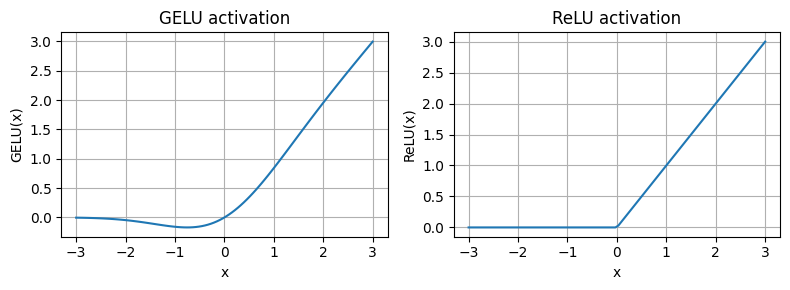

Key difference: GELU (left) has a smooth curve near zero.
ReLU (right) has a hard kink at zero  -  negative inputs get exactly zero gradient.
That hard kink causes dead neurons. GELU avoids it with a soft gate.


In [41]:
import matplotlib.pyplot as plt


class GELU(nn.Module):
    '''
    GELU activation  -  the smooth alternative to ReLU used in GPT-2.
    Uses a polynomial approximation of the exact Gaussian CDF-based formula.
    '''
    def __init__(self): super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * x**3)
        ))


# Visual comparison of GELU vs ReLU
x = torch.linspace(-3, 3, 100)
plt.figure(figsize=(8, 3))
for i, (fn, name) in enumerate([(GELU(), "GELU"), (nn.ReLU(), "ReLU")], 1):
    plt.subplot(1, 2, i)
    plt.plot(x.numpy(), fn(x).detach().numpy())
    plt.title(f"{name} activation"); plt.xlabel("x"); plt.ylabel(f"{name}(x)"); plt.grid(True)
plt.tight_layout(); plt.show()

print("Key difference: GELU (left) has a smooth curve near zero.")
print("ReLU (right) has a hard kink at zero  -  negative inputs get exactly zero gradient.")
print("That hard kink causes dead neurons. GELU avoids it with a soft gate.")

In [42]:
class FeedForward(nn.Module):
    '''
    Position-wise Feed-Forward Network (FFN) inside each Transformer block.

    Architecture: Linear(emb_dim -> 4*emb_dim) -> GELU -> Linear(4*emb_dim -> emb_dim)

    'Position-wise' means: the same FFN is applied independently to each token position.
    Unlike attention (which mixes information across tokens), the FFN operates on each
    token in isolation  -  processing the content but not the relationships.

    The expansion gives extra capacity for the model to store information.
    Input and output shapes are identical, which is required for residual connections.
    '''
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # expand: 768 -> 3072
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # contract: 3072 -> 768
        )
    def forward(self, x): return self.layers(x)


# Test: verify the shape is preserved
ffn = FeedForward(GPT_CONFIG_124M)
x   = torch.rand(2, 3, 768)    # [2 samples, 3 tokens, 768 dims]
print("FFN input  shape:", x.shape)       # [2, 3, 768]
print("FFN output shape:", ffn(x).shape)  # [2, 3, 768]  -  identical shape preserved

FFN input  shape: torch.Size([2, 3, 768])
FFN output shape: torch.Size([2, 3, 768])


---
## 16. Shortcut (Residual) Connections

### The problem: vanishing gradients
During training, we use **backpropagation** to compute how much each weight contributed to the error, then adjust the weights accordingly. Backpropagation works by passing gradient signals backward through all the layers.

In a deep network (12+ layers like GPT-2), this signal has to pass through many matrix multiplications and activation functions before reaching the early layers. Each operation tends to shrink the gradient slightly. By the time the signal reaches the first layers, it has become so small that those layers barely update  -  they effectively stop learning. This is the **vanishing gradient problem**.

### The solution: residual connections (shortcuts)
**Residual connections** (also called **skip connections** or **shortcut connections**) fix this by adding the input of a layer directly to its output:

```
output = layer(x) + x
```

This creates a direct path for the gradient to flow backward without passing through the layer's transformations. Even if the layer's gradient is tiny, the gradient can "skip" through the direct connection and reach earlier layers at full strength.

**Why does adding x to the output help?** It means the layer only needs to learn the *difference* (the "residual") between what it received and what the correct output should be. If the layer is not needed, it can just learn to output zero, and the input passes through unchanged. This makes optimization significantly easier.

The experiment below demonstrates this clearly: with residual connections, gradients remain strong in all layers. Without them, they shrink by several orders of magnitude as we go deeper.


In [43]:
class ExampleDeepNet(nn.Module):
    # A 5-layer deep network to demonstrate the vanishing gradient problem.
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i+1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            # If using shortcut AND the shapes match, add input to output
            x   = x + out if (self.use_shortcut and x.shape == out.shape) else out
        return x


def print_gradients(model, x):
    # Run a forward + backward pass and print gradient magnitudes per layer.
    loss = nn.MSELoss()(model(x), torch.tensor([[0.]]))
    loss.backward()
    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"  {name}: gradient mean = {param.grad.abs().mean().item():.8f}")


sizes = [3, 3, 3, 3, 3, 1]
x_in  = torch.tensor([[1., 0., -1.]])

print("WITHOUT residual connections:")
print("Gradients shrink as we go to earlier layers (vanishing gradient):")
torch.manual_seed(123)
print_gradients(ExampleDeepNet(sizes, use_shortcut=False), x_in)

print("\nWITH residual connections:")
print("Gradients stay strong across all layers:")
torch.manual_seed(123)
print_gradients(ExampleDeepNet(sizes, use_shortcut=True), x_in)

print("\nConclusion: residual connections allow stable training of deep networks.")

WITHOUT residual connections:
Gradients shrink as we go to earlier layers (vanishing gradient):
  layers.0.0.weight: gradient mean = 0.00020174
  layers.1.0.weight: gradient mean = 0.00012011
  layers.2.0.weight: gradient mean = 0.00071520
  layers.3.0.weight: gradient mean = 0.00139887
  layers.4.0.weight: gradient mean = 0.00504965

WITH residual connections:
Gradients stay strong across all layers:
  layers.0.0.weight: gradient mean = 0.22169799
  layers.1.0.weight: gradient mean = 0.20694111
  layers.2.0.weight: gradient mean = 0.32897002
  layers.3.0.weight: gradient mean = 0.26657331
  layers.4.0.weight: gradient mean = 1.32585442

Conclusion: residual connections allow stable training of deep networks.


---
## 17. Transformer Block & Full GPT Model

### What is a Transformer Block?
A **Transformer block** is the fundamental repeating unit of the GPT architecture. It combines everything we have built so far into one modular component. Each block contains exactly two sub-layers, each wrapped with a Pre-LayerNorm and a residual connection:

**Sub-layer 1  -  Multi-Head Self-Attention:**
`x = x + Dropout(MultiHeadAttention(LayerNorm(x)))`

**Sub-layer 2  -  Feed-Forward Network:**
`x = x + Dropout(FeedForward(LayerNorm(x)))`

The residual connections ensure gradients flow well, and the Pre-LayerNorm ensures stable activation distributions entering each sub-layer.

### The Full GPT Model
The complete GPT-2 124M model stacks 12 Transformer blocks between the input embedding layers and the output head:

```
Input Token IDs
    down
Token Embedding (50257 -> 768)  +  Positional Embedding (1024 -> 768)
    down  Dropout
    down  TransformerBlock × 12
    down  Final LayerNorm
    down
Output Head: Linear (768 -> 50257)
    down
Logits: one score per vocabulary token, per position
```

The **output head** projects from the 768-dim embedding space back to the 50,257-dim vocabulary space. The highest-scoring token at each position is the model's prediction for the next token.

### Weight tying
GPT-2 uses a technique called **weight tying**: the output head's weight matrix is shared with (tied to) the token embedding matrix. This makes sense intuitively  -  both matrices relate tokens to the same 768-dimensional embedding space, just in opposite directions (token ID -> vector vs. vector -> token ID). Weight tying reduces the parameter count by ~38 million without hurting performance.


In [44]:
class TransformerBlock(nn.Module):
    '''
    One full Transformer block: the repeating unit of the GPT architecture.

    Architecture (following GPT-2s Pre-LayerNorm design):
      Sub-layer 1: LayerNorm -> MultiHeadAttention -> Dropout -> + residual
      Sub-layer 2: LayerNorm -> FeedForward       -> Dropout -> + residual

    The Pre-LN approach (normalize before the sub-layer, not after) is empirically
    found to give more stable training for deep models.
    '''
    def __init__(self, cfg):
        super().__init__()
        self.att   = MultiHeadAttention(
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff    = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])   # applied before attention
        self.norm2 = LayerNorm(cfg["emb_dim"])   # applied before FFN
        self.drop  = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Sub-layer 1: Multi-Head Attention with residual
        x = x + self.drop(self.att(self.norm1(x)))
        # Sub-layer 2: Feed-Forward Network with residual
        x = x + self.drop(self.ff(self.norm2(x)))
        return x


# Verify shapes are preserved (required for residual connections)
torch.manual_seed(123)
x   = torch.rand(2, 4, 768)     # [2 samples, 4 tokens, 768 dims]
out = TransformerBlock(GPT_CONFIG_124M)(x)
print("TransformerBlock input  shape:", x.shape)    # [2, 4, 768]
print("TransformerBlock output shape:", out.shape)  # [2, 4, 768]  -  must match

TransformerBlock input  shape: torch.Size([2, 4, 768])
TransformerBlock output shape: torch.Size([2, 4, 768])


In [45]:
class GPTModel(nn.Module):
    '''
    Full GPT-2 style language model.

    Architecture:
        1. Token embedding: maps token IDs -> 768-dim vectors
        2. Positional embedding: maps position indices -> 768-dim vectors
        3. Sum of both embeddings -> Dropout
        4. 12 × TransformerBlock (the core processing)
        5. Final LayerNorm (stabilizes the output before the head)
        6. Output head: Linear(768 -> 50257) -> logit scores over vocabulary

    Weight tying: out_head.weight is shared with tok_emb.weight.
    This reduces parameters by ~38M (50257×768 params) and improves generalization
    because the same semantic space is used for both input encoding and output decoding.
    '''
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb    = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb    = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb   = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        b, T = in_idx.shape
        # Combine token and positional embeddings
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(T, device=in_idx.device))
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        return self.out_head(x)   # [batch, T, vocab_size]


torch.manual_seed(123)
model  = GPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Input shape: ", batch.shape)    # [2, 4]
print("Output shape:", logits.shape)   # [2, 4, 50257]

total = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total:,}")
print(f"Model memory (float32):      {total * 4 / 1024**2:.1f} MB")

Input shape:  torch.Size([2, 4])
Output shape: torch.Size([2, 4, 50257])

Total trainable parameters: 163,009,536
Model memory (float32):      621.8 MB


---
## 18. Text Generation

### How does a language model generate text?
Text generation is done **autoregressively**  -  one token at a time. At each step:
1. Feed the current sequence of tokens into the model
2. Get logit scores for the *next* token at the last position
3. Convert logits to probabilities via softmax
4. Pick the next token (greedy or sampled)
5. Append it to the sequence
6. Repeat from Step 1

### What are logits?
**Logits** are the raw, unnormalized scores that the model outputs. There is one logit per vocabulary token. A higher logit means the model thinks that token is more likely to come next. We apply **softmax** to convert these into actual probabilities that sum to 1.

### What is greedy decoding?
**Greedy decoding** always picks the token with the highest probability at each step. It is deterministic  -  the same input always produces the same output. It is fast and simple, but tends to produce repetitive, predictable text because the model always plays it safe.

### Why is the output nonsensical right now?
The model has random weights  -  it has not been trained yet. It is essentially generating random tokens. After training (Section 19), the weights will be tuned so the model assigns high probability to meaningful continuations.

### What does `model.eval()` do?
Calling `model.eval()` puts the model in evaluation mode. This disables dropout (which is only used during training) so the output is deterministic. Always call `model.eval()` before generating text or evaluating accuracy.


In [46]:
def text_to_token_ids(text, tokenizer):
    # Convert a string to a [1, T] tensor of token IDs.
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    return torch.tensor(encoded).unsqueeze(0)   # add batch dimension

def token_ids_to_text(token_ids, tokenizer):
    # Convert a [1, T] tensor of token IDs back to a string.
    return tokenizer.decode(token_ids.squeeze(0).tolist())


def generate_text_simple(model, idx, max_new_tokens, context_size):
    '''
    Greedy autoregressive text generation.

    Parameters:
        model          : the GPT model
        idx            : [1, T] tensor of starting token IDs (the prompt)
        max_new_tokens : how many new tokens to generate
        context_size   : the models maximum context window size

    At each step:
      1. Crop the sequence to the last `context_size` tokens (model cant see further back)
      2. Forward pass -> logits of shape [1, T, vocab_size]
      3. Take only the last positions logits [1, vocab_size]
      4. Softmax -> probabilities
      5. Argmax -> the most likely next token
      6. Append to the sequence and repeat
    '''
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]       # crop to context window
        with torch.no_grad():                   # no gradients needed for inference
            logits = model(idx_cond)
        # Take only the last position (predicting the NEXT token after the sequence)
        logits   = logits[:, -1, :]
        probas   = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # greedy pick
        idx      = torch.cat((idx, idx_next), dim=1)           # append to sequence
    return idx


# Reduce context length for faster testing in this notebook
GPT_CONFIG_124M["context_length"] = 256
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

prompt = "Every effort moves you"
out    = generate_text_simple(
    model, text_to_token_ids(prompt, tokenizer),
    max_new_tokens=6, context_size=GPT_CONFIG_124M["context_length"]
)
print("Prompt:", prompt)
print("Generated (untrained model  -  random weights):")
print(token_ids_to_text(out, tokenizer))
print("\nExpected: nonsensical output. The model has learned nothing yet.")
print("After training in Section 19, the output will be grammatically coherent.")

Prompt: Every effort moves you
Generated (untrained model  -  random weights):
Every effort moves you rentingetic wasnم refres Rex

Expected: nonsensical output. The model has learned nothing yet.
After training in Section 19, the output will be grammatically coherent.


---
## 19. Training the Model

### What is the training objective?
The model is trained with one goal: given a sequence of tokens, assign the **highest probability to the actual next token**. We measure how well it does this using **cross-entropy loss**.

### What is cross-entropy loss?
**Cross-entropy loss** measures how different the model's predicted probability distribution is from the true distribution (where the correct answer has probability 1 and everything else has probability 0).

Mathematically: `loss = -log(p_correct)` where `p_correct` is the probability the model assigned to the correct next token.

If the model assigned probability 1.0 to the correct token -> `loss = -log(1.0) = 0` (perfect).
If the model assigned probability 0.01 -> `loss = -log(0.01) ≈ 4.6` (very wrong).

We want to **minimize** this loss over all token predictions in all training samples.

### What is perplexity?
**Perplexity = exp(loss)**. It is a more human-interpretable metric. A perplexity of 10 means the model is "as confused as someone who had to guess uniformly among 10 equally likely options" at each step. Lower perplexity = better model.

### What is the AdamW optimizer?
**AdamW** (Adam with Weight Decay) is the optimizer that updates the model weights to reduce the loss. It combines two ideas:
- **Adam**: Adapts the learning rate for each parameter individually based on the history of its gradients. Parameters with large, consistent gradients get smaller updates; parameters with small or noisy gradients get larger updates.
- **Weight decay**: A regularization term that gently pushes all weights toward zero, preventing any single weight from becoming extremely large (which would cause overfitting).

### What is a training epoch?
One **epoch** means the model has seen every training sample exactly once. We train for multiple epochs so the model can refine its weights repeatedly. We also evaluate on the **validation set** periodically  -  data the model has never trained on  -  to check whether performance on unseen data is improving or degrading (overfitting).

### What is overfitting?
**Overfitting** is when the model memorizes the training data rather than learning generalizable patterns. You can detect it when training loss keeps decreasing but validation loss starts increasing or stagnating. On our tiny dataset (one short story), overfitting is expected  -  in practice, LLMs are trained on trillions of tokens.


In [47]:
# Demonstrate cross-entropy loss manually to build intuition
inputs_demo  = torch.tensor([[16833, 3626, 6100], [40, 1107, 588]])
targets_demo = torch.tensor([[3626,  6100, 345],  [1107, 588, 11311]])

with torch.no_grad():
    logits_demo = model(inputs_demo)

probas = torch.softmax(logits_demo, dim=-1)

# Extract the probability the model assigned to the CORRECT next token at each position
tp1 = probas[0, [0,1,2], targets_demo[0]]
tp2 = probas[1, [0,1,2], targets_demo[1]]
print("Probability assigned to correct tokens (text 1):", tp1)
print("Probability assigned to correct tokens (text 2):", tp2)
print("\n(These are very small because the model is untrained and essentially guessing)")

# Manual cross-entropy: average negative log probability of correct tokens
manual_loss = -torch.mean(torch.log(torch.cat((tp1, tp2))))
print(f"\nManual cross-entropy loss: {manual_loss:.4f}")

# PyTorch's built-in version (numerically more stable  -  identical result)
loss = torch.nn.functional.cross_entropy(
    logits_demo.flatten(0, 1), targets_demo.flatten())
print(f"PyTorch cross_entropy:     {loss:.4f}")

Probability assigned to correct tokens (text 1): tensor([0.0001, 0.0000, 0.0000])
Probability assigned to correct tokens (text 2): tensor([0.0000, 0.0001, 0.0000])

(These are very small because the model is untrained and essentially guessing)

Manual cross-entropy loss: 10.7940
PyTorch cross_entropy:     10.7940


In [48]:
# Create 90/10 train/validation split from our corpus
split_idx  = int(0.90 * len(raw_text))
train_data = raw_text[:split_idx]
val_data   = raw_text[split_idx:]

ctx = GPT_CONFIG_124M["context_length"]
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data, batch_size=4, max_length=ctx, stride=ctx,
    drop_last=True, shuffle=True, num_workers=0)
val_loader = create_dataloader_v1(
    val_data, batch_size=4, max_length=ctx, stride=ctx,
    drop_last=False, shuffle=False, num_workers=0)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches:   4
Validation batches: 1


In [49]:
def calc_loss_batch(inputs, targets, model, device):
    # Compute cross-entropy loss for a single batch.
    logits = model(inputs.to(device))
    return torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), targets.to(device).flatten())

def calc_loss_loader(loader, model, device, num_batches=None):
    # Average cross-entropy loss over an entire DataLoader.
    n    = min(num_batches or len(loader), len(loader))
    total = sum(
        calc_loss_batch(x, y, model, device).item()
        for i, (x, y) in enumerate(loader) if i < n
    )
    return total / n

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    # Evaluate on both train and val splits without updating weights.
    model.eval()
    with torch.no_grad():
        tl = calc_loss_loader(train_loader, model, device, eval_iter)
        vl = calc_loss_loader(val_loader,   model, device, eval_iter)
    model.train()
    return tl, vl

def generate_and_print_sample(model, tokenizer, device, start_context):
    # Generate a short sample text to visually monitor training progress.
    model.eval()
    ctx_size = model.pos_emb.weight.shape[0]
    with torch.no_grad():
        out = generate_text_simple(
            model, text_to_token_ids(start_context, tokenizer).to(device),
            max_new_tokens=50, context_size=ctx_size)
    print(token_ids_to_text(out, tokenizer).replace("\n", " "))
    model.train()


def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    '''
    Main training loop.

    For each epoch:
      - For each batch: zero gradients -> forward pass -> compute loss
        -> backpropagation -> optimizer step
      - Every eval_freq steps: log train and val loss
      - After each epoch: generate a sample text to see progress visually

    Parameters:
        eval_freq  : how often (in optimizer steps) to evaluate and log losses
        eval_iter  : how many batches to use for evaluation (subset, for speed)
    '''
    train_losses, val_losses, tokens_seen_list = [], [], []
    tokens_seen, step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for x, y in train_loader:
            optimizer.zero_grad()                              # clear old gradients
            loss = calc_loss_batch(x, y, model, device)
            loss.backward()                                    # compute new gradients
            optimizer.step()                                   # update weights
            tokens_seen += x.numel()
            step += 1
            if step % eval_freq == 0:
                tl, vl = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tl); val_losses.append(vl)
                tokens_seen_list.append(tokens_seen)
                print(f"Ep {epoch+1} Step {step:05d}: Train loss {tl:.3f}  Val loss {vl:.3f}")
        print("Sample text after epoch", epoch+1, ": ", end="")
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_losses, val_losses, tokens_seen_list


device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model     = GPTModel(GPT_CONFIG_124M)
model.to(device)
# lr=0.0004: learning rate  -  how large a step to take each update
# weight_decay=0.1: L2 regularization coefficient  -  keeps weights small
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=10, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer)

Ep 1 Step 00000: Train loss 9.712  Val loss 9.836
Sample text after epoch 1 : Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 Step 00005: Train loss 7.746  Val loss 8.035
Sample text after epoch 2 : Every effort moves you the the the the the the the the the the the the the the the the the the the the the the the the                          
Ep 3 Step 00010: Train loss 6.267  Val loss 6.889
Sample text after epoch 3 : Every effort moves you, and, and the, and, and, the, and, and, and, and, and, the, and, and, and the, and the, and, and the, and, the, and, the, and, and
Ep 4 Step 00015: Train loss 5.579  Val loss 6.427
Sample text after epoch 4 : Every effort moves you. ".  ". ", and I had. I had the, I had the the, I had the, and I had the the the. I had the the. I had the, and, and I had the
Sample text after epoch 5 : Every effort moves you, and to the to the of the to the to the of the of the of the                                
Ep 6 Step 00020: Train

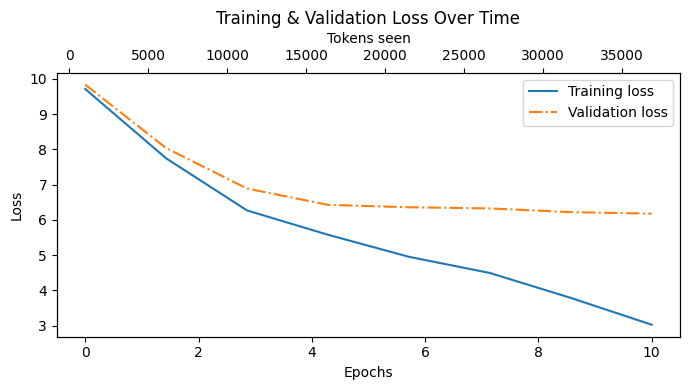

What to look for in this plot:
  - Both losses should decrease early  -  the model is learning.
  - If training loss keeps falling but val loss stagnates -> overfitting.
  - On this tiny dataset, overfitting after epoch 2 is expected and normal.


In [50]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

epochs = torch.linspace(0, 10, len(train_losses))
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(epochs, train_losses, label="Training loss")
ax1.plot(epochs, val_losses, linestyle="-.", label="Validation loss")
ax1.set_xlabel("Epochs"); ax1.set_ylabel("Loss"); ax1.legend()
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2 = ax1.twiny()
ax2.plot(tokens_seen, train_losses, alpha=0); ax2.set_xlabel("Tokens seen")
plt.title("Training & Validation Loss Over Time"); plt.tight_layout(); plt.show()

print("What to look for in this plot:")
print("  - Both losses should decrease early  -  the model is learning.")
print("  - If training loss keeps falling but val loss stagnates -> overfitting.")
print("  - On this tiny dataset, overfitting after epoch 2 is expected and normal.")

---
## 20. Decoding Strategies  -  Temperature & Top-k Sampling

### The problem with greedy decoding
Greedy decoding always picks the single highest-probability token. This tends to produce text that is repetitive and predictable  -  the model plays it too safe. If "the" is the most likely word, it picks "the" every time, even if "a" or "this" would also be natural and more interesting.

### Temperature scaling
**Temperature** is a hyperparameter that controls how "confident" or "random" the model's token selection is. We divide the logits by a temperature value T before applying softmax:

```
probabilities = softmax(logits / T)
```

- **T = 1.0**: No change. The model uses its raw learned probabilities.
- **T < 1.0** (e.g., 0.5): The distribution becomes *sharper*  -  the highest-probability tokens get relatively even higher probability, and low-probability tokens get pushed toward zero. The output is more deterministic and focused.
- **T > 1.0** (e.g., 1.5): The distribution becomes *flatter*  -  probabilities spread out more evenly among many tokens. The output is more random and creative (but risks being incoherent).

**Why does dividing by T change the sharpness?** Because `softmax(x/T)` = `softmax(x)^(1/T)`. Raising probabilities to a power < 1 makes them more uniform; raising to a power > 1 makes the highest ones dominate even more.

### Top-k sampling
**Top-k sampling** is a complementary technique. Before sampling, we keep only the `k` highest-probability tokens and set all other tokens to −∞ (zero probability after softmax). Then we sample from this restricted set.

This prevents the model from ever generating a token that is clearly inappropriate (very low probability), while still allowing randomness among the reasonable options.

Combining temperature > 1 with top-k sampling gives creative, diverse output that still makes sense.


In [51]:
# Small vocabulary example to visualize the effects clearly
vocab_demo  = {"closer":0,"every":1,"effort":2,"forward":3,
               "inches":4,"moves":5,"pizza":6,"toward":7,"you":8}
inv_vocab   = {v: k for k, v in vocab_demo.items()}
next_logits = torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
probas      = torch.softmax(next_logits, dim=0)

print("Greedy decoding (always picks argmax):")
print(f"  Selected token: '{inv_vocab[torch.argmax(probas).item()]}'  -  always the same.")

print("\nStochastic sampling (picks based on probability distribution):")
torch.manual_seed(123)
print(f"  Selected token: '{inv_vocab[torch.multinomial(probas, num_samples=1).item()]}'")
print("  This can vary  -  the model explores different options.")

Greedy decoding (always picks argmax):
  Selected token: 'forward'  -  always the same.

Stochastic sampling (picks based on probability distribution):
  Selected token: 'forward'
  This can vary  -  the model explores different options.


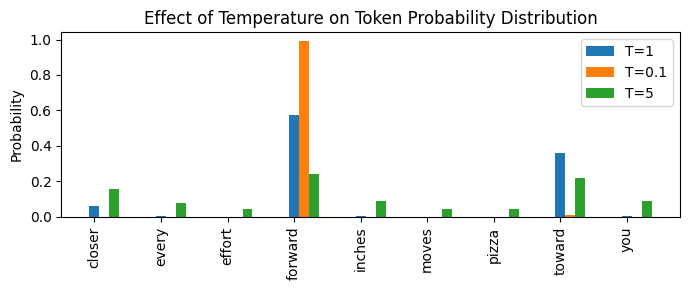

T=1 (blue):  original distribution
T=0.1 (orange): very sharp  -  'forward' gets nearly all the probability
T=5 (green):  very flat  -  all tokens have nearly equal probability


In [52]:
def softmax_with_temperature(logits, T):
    # Apply temperature scaling before softmax.
    return torch.softmax(logits / T, dim=0)

# Visualize how temperature reshapes the distribution
temps = [1, 0.1, 5]
x     = torch.arange(len(vocab_demo))
fig, ax = plt.subplots(figsize=(7, 3))
for i, T in enumerate(temps):
    ax.bar(x + i*0.15, softmax_with_temperature(next_logits, T), 0.15, label=f"T={T}")
ax.set_ylabel("Probability"); ax.set_xticks(x)
ax.set_xticklabels(vocab_demo.keys(), rotation=90); ax.legend()
plt.title("Effect of Temperature on Token Probability Distribution")
plt.tight_layout(); plt.show()

print("T=1 (blue):  original distribution")
print("T=0.1 (orange): very sharp  -  'forward' gets nearly all the probability")
print("T=5 (green):  very flat  -  all tokens have nearly equal probability")

In [53]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    '''
    Enhanced text generation with temperature scaling and top-k sampling.

    Parameters:
        temperature : 0.0 = greedy (argmax); >0 = stochastic with this temperature
        top_k       : if set, only consider the top-k most likely tokens at each step
        eos_id      : optional  -  stop generation if this token is produced
    '''
    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model(idx[:, -context_size:])[:, -1, :]

        if top_k is not None:
            # Keep only top-k scores; set all others to -inf (zero after softmax)
            top_vals, _ = torch.topk(logits, top_k)
            logits = torch.where(logits < top_vals[:, -1],
                                 torch.tensor(float("-inf")), logits)

        if temperature > 0.0:
            # Stochastic: sample from temperature-scaled distribution
            idx_next = torch.multinomial(
                torch.softmax(logits / temperature, dim=-1), num_samples=1)
        else:
            # Greedy: always pick the highest-probability token
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


model.to("cpu"); model.eval()
torch.manual_seed(123)
out = generate(
    model, text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15, context_size=GPT_CONFIG_124M["context_length"],
    top_k=25, temperature=1.4)
print("Generated text (top_k=25, temperature=1.4):")
print(token_ids_to_text(out, tokenizer))
print("\nWith temperature=1.4 and top_k=25, the output is more varied than greedy decoding.")

Generated text (top_k=25, temperature=1.4):
Every effort moves you not to work up. "Mrs. Gisburn! by his head

With temperature=1.4 and top_k=25, the output is more varied than greedy decoding.


---
## 21. Saving & Loading the Model

### Why save the model?
Training takes time and compute. Once a model is trained, we save its weights to disk so we can:
- Load it later for inference without retraining
- Share it with others
- Resume training from where we left off

### What is a state dict?
A state dict (state dictionary) is a Python dictionary that maps every parameter name in the model to its current tensor value. It captures the entire learned state of the model in a compact, serializable format.

### Two approaches:
Option 1  -  Save weights only: Saves just the models state dict. Compact and sufficient if you only need inference. To load, you must recreate the model architecture yourself first, then load the weights into it.

Option 2  -  Save weights + optimizer state: Also saves the optimizers state dict. The optimizer state contains per-parameter momentum and adaptive learning rates that AdamW has accumulated over training. This information is essential for resuming training correctly  -  without it, the optimizer restarts from scratch, and the first few steps of continued training are less efficient.


In [54]:
# Option 1: Save model weights only (sufficient for inference)
torch.save(model.state_dict(), "model.pth")

# Load: recreate the architecture first, then populate with saved weights
model_loaded = GPTModel(GPT_CONFIG_124M)
model_loaded.load_state_dict(torch.load("model.pth", map_location=device))
model_loaded.eval()
print("Model weights loaded successfully. Ready for inference.")

Model weights loaded successfully. Ready for inference.


In [55]:
# Option 2: Save model + optimizer (required for resuming training)
torch.save({
    "model_state_dict":     model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}, "model_and_optimizer.pth")

# Load and fully restore training state
ckpt         = torch.load("model_and_optimizer.pth", map_location=device)
model_resume = GPTModel(GPT_CONFIG_124M)
model_resume.load_state_dict(ckpt["model_state_dict"])
opt_resume   = torch.optim.AdamW(model_resume.parameters(), lr=5e-4, weight_decay=0.1)
opt_resume.load_state_dict(ckpt["optimizer_state_dict"])
model_resume.train()
print("Full checkpoint loaded.")
print("Both model weights AND optimizer momentum/adaptive-lr are restored.")
print("Training can continue exactly where it left off.")

Full checkpoint loaded.
Both model weights AND optimizer momentum/adaptive-lr are restored.
Training can continue exactly where it left off.


---
## 22. Loading Pretrained GPT-2 Weights

### Why use pretrained weights?
Training a 124M-parameter model from scratch on a tiny corpus (one short story) gives poor results  -  the model has seen far too little text to learn the full complexity of language. In practice, GPT-style models are trained on hundreds of billions of tokens.

OpenAI trained GPT-2 on 40 GB of web text and has made the weights publicly available. We can load these weights directly into our custom `GPTModel` architecture, immediately giving our model strong language generation capabilities  -  without any training on our end.

This process is called using pretrained weights or transfer learning: take a model trained by someone else on massive data, and use its learned knowledge directly.

### Why is weight mapping needed?
Our `GPTModel` and OpenAIs GPT-2 checkpoint store parameters with different names and in different formats. Most notably, OpenAI stored the query, key, and value weight matrices as a single combined matrix called `c_attn`, while our implementation keeps them as three separate matrices `W_query`, `W_key`, `W_value`. We use `numpy.split` to divide the combined matrix into three pieces before loading.

### What does this prove?
After loading, our model produces coherent, grammatically correct text. This confirms that our architecture is mathematically equivalent to the original GPT-2  -  we built the same model from scratch.


In [56]:
!pip install tensorflow>=2.15.0 tqdm>=4.66

In [57]:
import urllib.request

# Download the weight-loading utility from the books GitHub repository
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
       "/main/ch05/01_main-chapter-code/gpt_download.py")
urllib.request.urlretrieve(url, "gpt_download.py")
print("Downloaded gpt_download.py")

Downloaded gpt_download.py


In [58]:
from gpt_download import download_and_load_gpt2

# Downloads ~500MB of GPT-2 124M weights from OpenAIs servers
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")
print("GPT-2 settings:", settings)
print("Checkpoint keys:", list(params.keys()))
print("Token embedding shape:", params["wte"].shape)   # [50257, 768]

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 313kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 4.04MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 552kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:30<00:00, 16.5MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 27.2MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 2.34MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.82MiB/s]


GPT-2 settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Checkpoint keys: ['blocks', 'b', 'g', 'wpe', 'wte']
Token embedding shape: (50257, 768)


In [59]:
# GPT-2 comes in 4 sizes  -  we load the smallest (124M)
# All use the same architecture, just different scale
model_configs = {
    "gpt2-small (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)":    {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Build the config for GPT-2 small and create our model
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs["gpt2-small (124M)"])
# GPT-2 uses a 1024-token context window and has bias in QKV (unlike our default)
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()
print("Created GPTModel with config:", NEW_CONFIG)

Created GPTModel with config: {'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


In [60]:
import numpy as np


def assign(left, right):
    '''
    Assign a numpy array (from the checkpoint) to a PyTorch parameter.
    Shape validation ensures we are mapping the right weight to the right parameter.
    '''
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch: model has {left.shape}, checkpoint has {right.shape}")
    return nn.Parameter(torch.tensor(right))


def load_weights_into_gpt(gpt, params):
    '''
    Map OpenAI's GPT-2 checkpoint weights into our GPTModel.

    The main remapping challenge:
    - OpenAI stores Q, K, V as ONE combined matrix 'c_attn' of shape [d_model, 3*d_model]
    - Our model stores them as three separate matrices W_query, W_key, W_value
    - We use np.split to divide the combined matrix into three equal parts
    '''
    # Positional and token embeddings map directly
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        # Split the combined QKV weight matrix into three parts
        q_w, k_w, v_w = np.split(params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1)
        q_b, k_b, v_b = np.split(params["blocks"][b]["attn"]["c_attn"]["b"], 3)

        gpt.trf_blocks[b].att.W_query.weight = assign(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign(gpt.trf_blocks[b].att.W_key.weight,   k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        gpt.trf_blocks[b].att.W_query.bias   = assign(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias     = assign(gpt.trf_blocks[b].att.W_key.bias,   k_b)
        gpt.trf_blocks[b].att.W_value.bias   = assign(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(gpt.trf_blocks[b].att.out_proj.weight, params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias   = assign(gpt.trf_blocks[b].att.out_proj.bias,   params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign(gpt.trf_blocks[b].ff.layers[0].weight, params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias   = assign(gpt.trf_blocks[b].ff.layers[0].bias,   params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(gpt.trf_blocks[b].ff.layers[2].weight, params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias   = assign(gpt.trf_blocks[b].ff.layers[2].bias,   params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(gpt.trf_blocks[b].norm1.scale, params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(gpt.trf_blocks[b].norm1.shift, params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(gpt.trf_blocks[b].norm2.scale, params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(gpt.trf_blocks[b].norm2.shift, params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    # Weight tying: output head shares weights with token embedding (same semantic space)
    gpt.out_head.weight  = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device)
print("All pretrained GPT-2 weights successfully loaded into our custom architecture.")

All pretrained GPT-2 weights successfully loaded into our custom architecture.


In [61]:
# Generate text using the pretrained weights
torch.manual_seed(123)
out = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50, temperature=1.5)

print("Prompt: 'Every effort moves you'")
print("Generated text (pretrained GPT-2 weights):")
print(token_ids_to_text(out, tokenizer))
print()
print("The output is coherent and grammatically correct.")
print("This confirms our from-scratch architecture is mathematically identical to GPT-2.")

Prompt: 'Every effort moves you'
Generated text (pretrained GPT-2 weights):
Every effort moves you as far as the hand can go until the end of your turn unless something interrupts your control flow. As you may observe I

The output is coherent and grammatically correct.
This confirms our from-scratch architecture is mathematically identical to GPT-2.


TBC